In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [29]:
import matplotlib.pyplot as plt
from cns.process.binning import group_bins, sum_cns
from cns.utils.selection import get_cns_for_type
from cns.display.plot import fig_lines, plot_lines
from cns.data_utils import load_merged_samples, load_merged_bins, select_CNS_samples

In [3]:
samples_df = load_merged_samples()
cns_df = load_merged_bins(samples_df, "3MB")

<Axes: xlabel='type'>

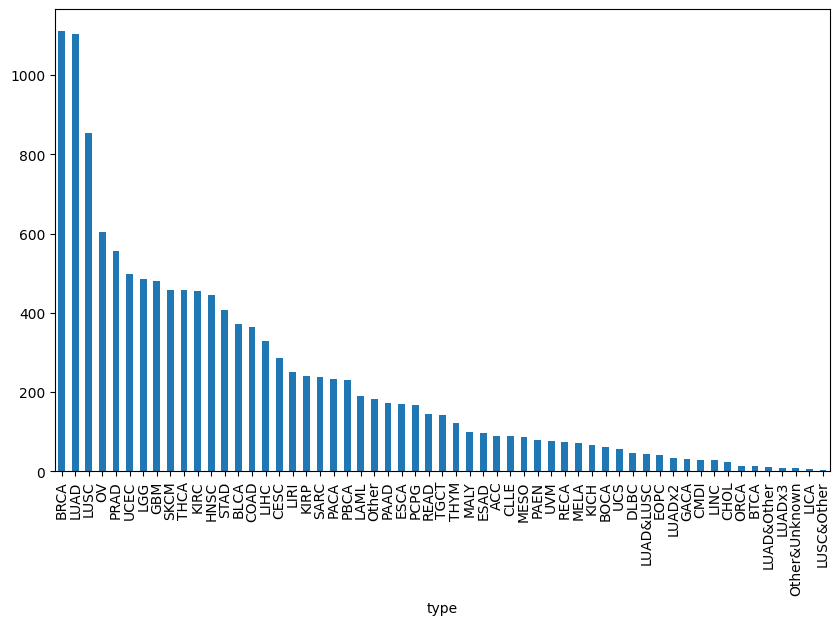

In [4]:
plt.rcParams["figure.figsize"] = (10,6)
samples_df["type"].value_counts().plot(kind="bar")

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

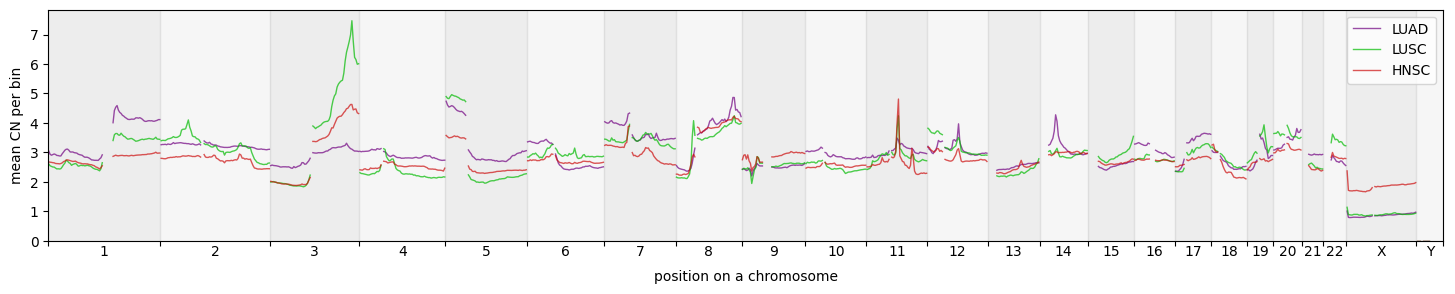

In [13]:
types = ["LUAD", "LUSC", "HNSC"]
selection = [group_bins(get_cns_for_type(cns_df, samples_df, type)) for type in types]

['LUAD', 'LUSC', 'HNSC']


(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

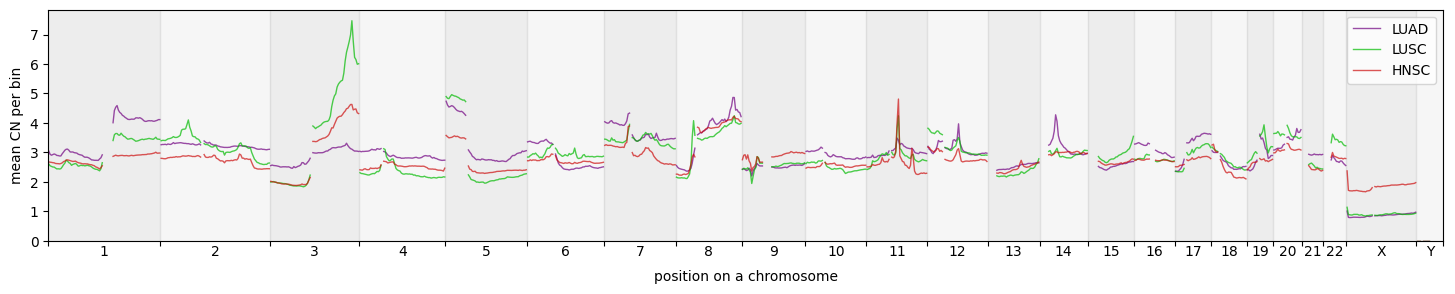

In [20]:
fig_lines(selection, types, column="total_cn")

In [6]:
tcga_set = samples_df.query("source == 'TCGA'")
tcga_cns = select_CNS_samples(cns_df, tcga_set)
top_6 = tcga_set.value_counts("type")[:6].index.values

In [7]:
selection_tcga = [group_bins(get_cns_for_type(cns_df, samples_df, type)) for type in top_6]

(<Figure size 3600x600 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

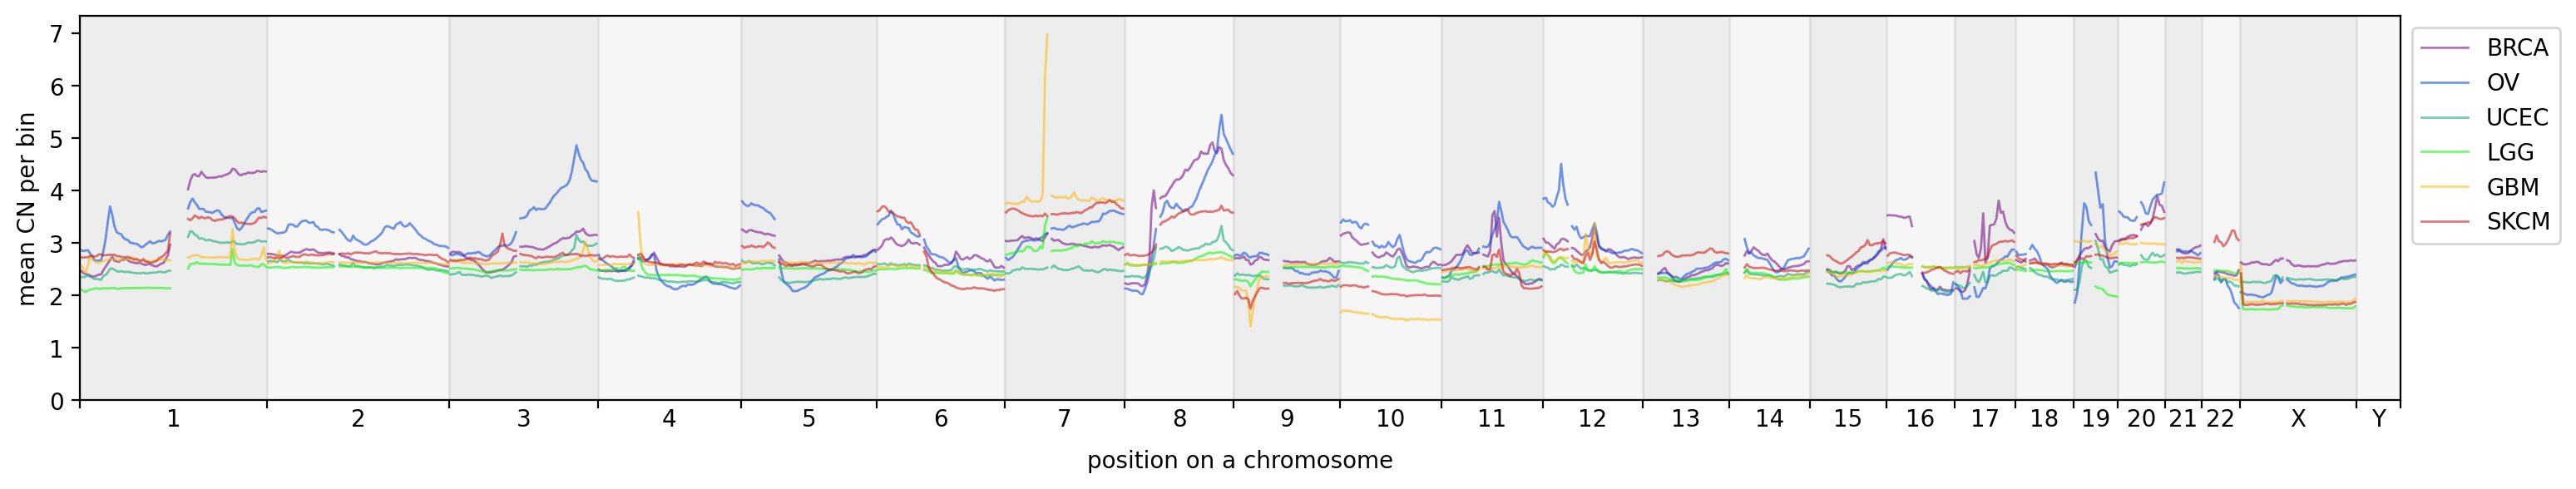

In [24]:
fig_lines(selection_tcga, top_6, column="total_cn", dpi=200)

In [25]:
above_50 = samples_df["type"].value_counts().where(lambda x: x >= 50).where(lambda x: x != "Other").dropna().index.values
all_samples = samples_df.query("type in @above_50")
sub_samples = all_samples.groupby('type').apply(lambda x: x.sample(n=50, replace=True) if len(x) > 50 else x, include_groups=False).reset_index().set_index('sample_id')
# select only 50 samples for each type


In [26]:
sub_samples.head()

,type,sex,chrom_count,chrom_missing,cover_bases_aut,cover_bases_sex,cover_bases_tot,cover_frac_aut,cover_frac_sex,cover_frac_tot,...,ane_major_cn_frac_aut,ane_minor_cn_frac_aut,ane_total_cn_frac_aut,ane_major_cn_sex,ane_minor_cn_sex,ane_total_cn_sex,ane_major_cn_frac_sex,ane_minor_cn_frac_sex,ane_total_cn_frac_sex,source
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-OR-A5LK,ACC,xy,23.0,['chrY'],2793453195,155047822,2948501017,0.969601,0.722348,0.952457,...,0.922764,0.962739,0.441622,214644126,2703511,214644126,1.0,0.012595,1.000000,TCGA
TCGA-OR-A5L5,ACC,xx,23.0,[],2793464155,155063154,2948527309,0.969605,0.998664,0.971091,...,1.000000,0.985403,1.000000,155270560,155270560,153558022,1.0,1.000000,0.988971,TCGA
TCGA-PA-A5YG,ACC,xy,23.0,['chrY'],2793459622,155065129,2948524751,0.969603,0.722429,0.952465,...,1.000000,1.000000,0.262050,214644126,2703511,214644126,1.0,0.012595,1.000000,TCGA
TCGA-OR-A5JA,ACC,xx,23.0,[],2793327009,155059385,2948386394,0.969557,0.998640,0.971045,...,1.000000,0.937429,0.996387,155270560,79717612,155270560,1.0,0.513411,1.000000,TCGA
TCGA-OR-A5L5,ACC,xx,23.0,[],2793464155,155063154,2948527309,0.969605,0.998664,0.971091,...,1.000000,0.985403,1.000000,155270560,155270560,153558022,1.0,1.000000,0.988971,TCGA


(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on a chromosome', ylabel='mean CN per bin'>)

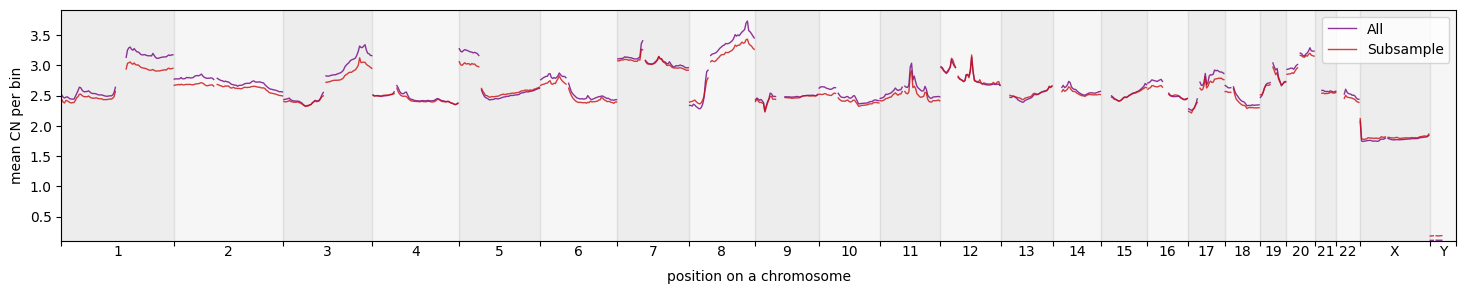

In [31]:
selection = [sum_cns(group_bins(select_CNS_samples(cns_df, samples))) for samples in [all_samples, sub_samples]]
fig_lines(selection, ["All", "Subsample"], column="total_cn", dpi=100)